In [65]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')


In [66]:
df=pd.read_csv('Iris.csv')


In [67]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# EDA


In [68]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [70]:
df.notnull().sum()

Id               150
SepalLengthCm    150
SepalWidthCm     150
PetalLengthCm    150
PetalWidthCm     150
Species          150
dtype: int64

In [71]:
df.notna().sum()

Id               150
SepalLengthCm    150
SepalWidthCm     150
PetalLengthCm    150
PetalWidthCm     150
Species          150
dtype: int64

In [72]:
df.duplicated().sum()

np.int64(0)

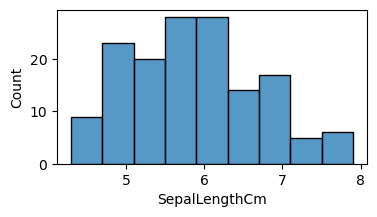

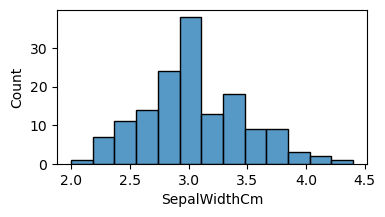

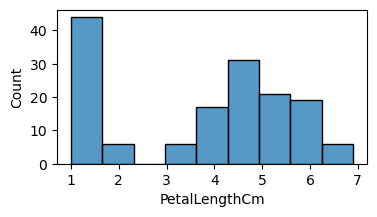

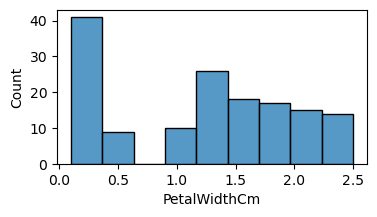

In [73]:
numeric_colums=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
for cols in numeric_colums:
    plt.figure(figsize=(4,2))
    sns.histplot(df[cols])

<Axes: xlabel='PetalWidthCm'>

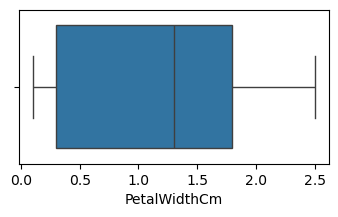

In [74]:
plt.figure(figsize=(4,2))
sns.boxplot(x=df['PetalWidthCm'])

<Axes: xlabel='PetalLengthCm'>

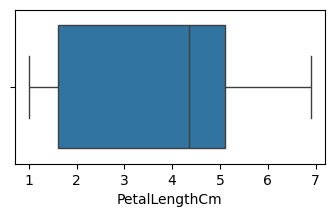

In [75]:
plt.figure(figsize=(4,2))
sns.boxplot(x=df['PetalLengthCm'])

In [76]:
#in the upper fig there is skewness of data towards the upper quartile.
#skewness generally doesnt affect models like decision tree but affect linear models,knn,svm etc.
#to remove skewness perform transformation and scaling

<Axes: xlabel='Species', ylabel='count'>

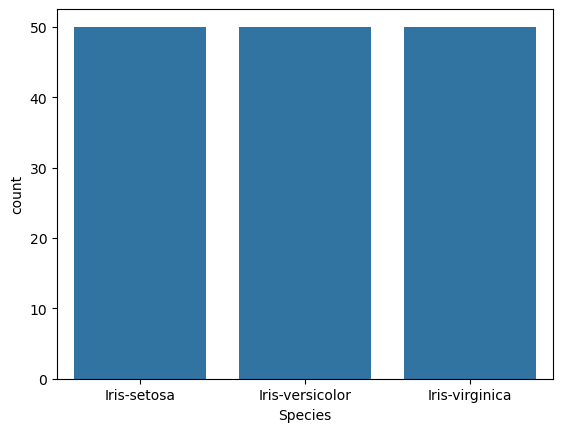

In [77]:
sns.countplot(x=df['Species'])

<Axes: >

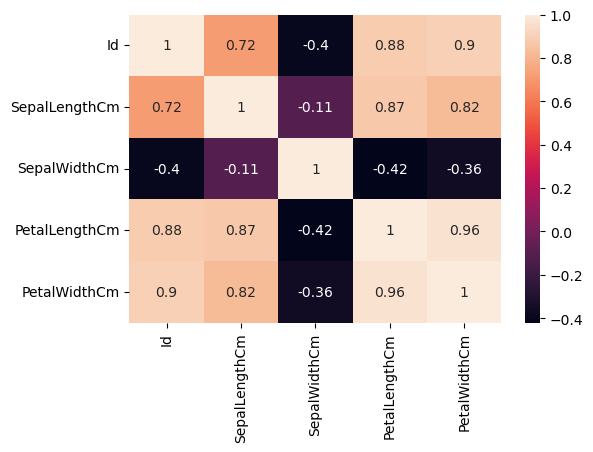

In [78]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and preprocessing

In [79]:
#Encoding the data

In [80]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [81]:
df['Species']=df['Species'].map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2})

In [82]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [83]:
df=df.drop('Id',axis=1)

In [84]:
df['petalarea']=df['PetalLengthCm']*df['PetalWidthCm']
#adding a new feature name petal area
#area=length*breadth;

In [85]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,petalarea
0,5.1,3.5,1.4,0.2,0,0.28
1,4.9,3.0,1.4,0.2,0,0.28
2,4.7,3.2,1.3,0.2,0,0.26
3,4.6,3.1,1.5,0.2,0,0.30
4,5.0,3.6,1.4,0.2,0,0.28
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,11.96
146,6.3,2.5,5.0,1.9,2,9.50
147,6.5,3.0,5.2,2.0,2,10.40
148,6.2,3.4,5.4,2.3,2,12.42


In [98]:
x=df.drop('Species',axis=1)
x['PetalArea'] = x['PetalLengthCm'] * x['PetalWidthCm']


In [87]:
x=df.drop('Species',axis=1)

In [99]:
y=df['Species']

In [89]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [100]:
from sklearn.tree import DecisionTreeClassifier

In [91]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [92]:
y_pred=model.predict(x_test)

In [93]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [94]:
accuracy_score(y_pred,y_test)

0.9666666666666667

In [95]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      1.00      0.94         8
           2       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [96]:
# Example of giving external input.
sample = [[6.0, 2.9, 4.5, 1.5,4.5*1.5]]  # last value is PetalArea
prediction = model.predict(sample)
print("Predicted class:", prediction)
species = {0: "Iris-setosa", 1: "Iris-versicolor", 2: "Iris-virginica"}
print("Predicted species:", species[prediction[0]])


Predicted class: [1]
Predicted species: Iris-versicolor


In [101]:
import joblib

joblib.dump(model, 'decisiontree_model.pkl')
print('Saved decisiontree_model.pkl')

Saved decisiontree_model.pkl
